# Задание: Многовидовая 3D-реконструкция  
**Цель:** Восстановить трёхмерное облако точек по трём проекциям с неизвестных ракурсов.

**Срок:** дедлайн в 23:30 20 февраля.

# Входные данные
Вам дан список из трёх проекций (`data.pth`), а также массив цветов точек для удобства визуализации (`rgbs.pth`). Как можно видеть, каждый ракурс содержит лишь часть точек в облаке, а вашей целью будет совместить все эти части, получив трёхмерное облако точек.

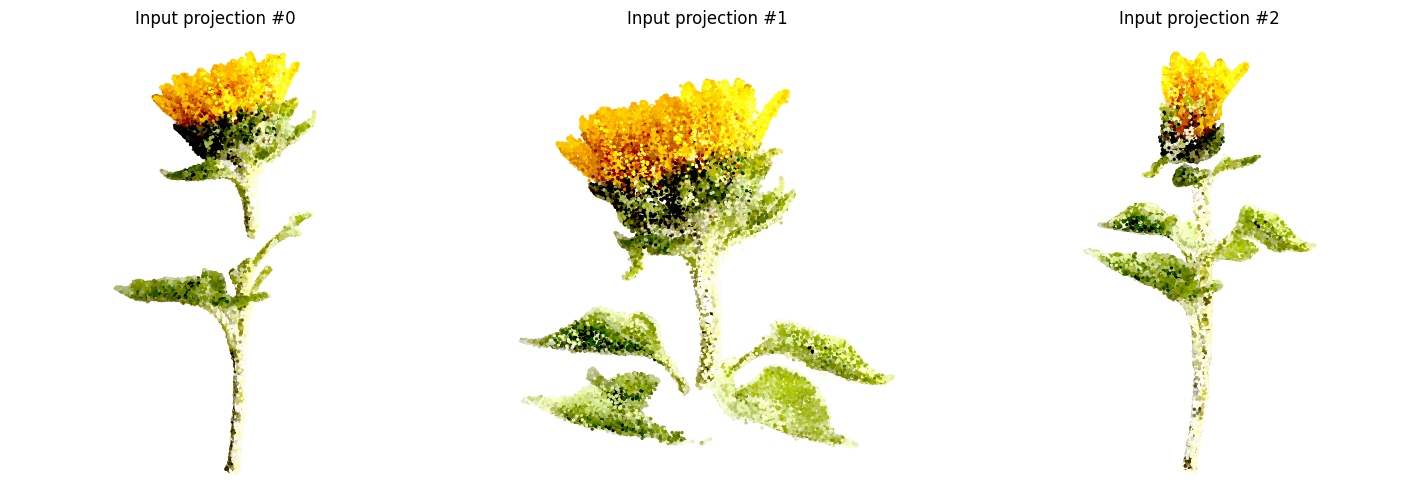

In [2]:
import torch
import matplotlib.pylab as plt

projections = torch.load('data.pth')
rgbs = torch.load('rgbs.pth')

fig, axes = plt.subplots(1, 3, figsize=(18,6))
for n_camera, (d, ax) in enumerate(zip(projections, axes.flatten())):
    xs, ys = d['coordinates'].T
    indices = d['ids']
    ax.scatter(xs, ys, c=rgbs[indices], s=2.)
    ax.axis('equal')
    ax.axis('off')
    ax.set_title(f'Input projection #{n_camera}')

Каждая проекция получена с неизвестного ракурса с помощью пинхол камеры с фокусным расстоянием 50мм, матрица внутренних параметров имеет следующий вид:

```python
# параметры объектива указывают в миллиметрах, а размер сенсора соответствет ширине кадра плёнки
f = 50
sensor_size = 36
# по ним строим матрицу внутренних параметров
K = torch.tensor([
    [2 * f / sensor_size, 0.0, 0.0],
    [0.0, 2 * f / sensor_size, 0.0],
    [0.0,                 0.0, 1.0]
])
```

Каждая проекция задана словарём. Поле `ids` содержит массив с номерами точек в исходном облаке (по ним можно найти соответствия между парой ракурсов), а поле `coordinates` неоднородные координаты в плоскости сенсора. Каждая точка видна как минимум с двух ракурсов.

```python
projection_example = {
    'ids': torch.tensor([0, 1, 2], dtype=torch.int64),
    'coordinates': torch.tensor([[0.1, 0.2], [0.2, 0.3], [0.3, 0.4]], dtype=torch.float32)
}
```

# Формат решения

Решение должно состоять из двух компонент:
1. Массив с реконструкцией исходного трёхмерного облака точек,
2. Отчёт в формате (PDF/Jupyter/Python/Markdown), с подробным описанием вашего метода и его реализацией.

## Облако точек

*Массив* будет использован для автоматизации проверки, но оценка за задание будет определяться в первую очередь на основе отчёта.
Ожидаемый формат массива - тензор размера $(N, 3)$.
```python
solution_example = torch.tensor([[0.1, 0.2, 0.0], [0.2, 0.3, 0.0], [0.3, 0.4, 0.0]], dtype=torch.float32)
```
Масштаб облака точек должен быть выбран исходя из предположения, что расстояние между первой и второй камерой равно *(условной)* единице.

## Отчёт

Вы свободны выбирать свой путь решения, но присланное решение не должно опираться на внешние реализации алгоритмов поиска фундаментальной матрицы, PnP, триангуляции и подобных. Иными словами, решение может использовать методы из библиотек torch`/`numpy, а более сложные алгоритмы должны быть реализованы внутри.

Для отладки и упрощения проверки рекомендуем включить в отчёт визуализации и тесты промежуточных шагов с пояснениями. Также полезной может оказаться визуализация облака точек:
```python
import open3d as o3d
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)
o3d.visualization.draw_geometries([pcd])
```

In [3]:
rgbs

tensor([[0.9922, 0.6902, 0.0000],
        [0.9922, 0.7922, 0.0000],
        [0.9922, 0.8275, 0.0000],
        ...,
        [0.9765, 0.6627, 0.0000],
        [0.9882, 0.6784, 0.0000],
        [0.9922, 0.7843, 0.0000]])

In [4]:
projections

[{'ids': tensor([    0,     1,     2,  ..., 76435, 76436, 76437]),
  'coordinates': tensor([[-0.1229,  0.8619],
          [-0.1898,  0.8531],
          [-0.1898,  0.8488],
          ...,
          [-0.3384,  0.7602],
          [-0.3313,  0.7568],
          [-0.3501,  0.7382]])},
 {'ids': tensor([    0,     1,     2,  ..., 76435, 76436, 76437]),
  'coordinates': tensor([[-0.3114,  0.8269],
          [-0.3808,  0.8178],
          [-0.3778,  0.8145],
          ...,
          [-0.4321,  0.7603],
          [-0.4245,  0.7571],
          [-0.4598,  0.7330]])},
 {'ids': tensor([   40,    41,    54,  ..., 76403, 76404, 76408]),
  'coordinates': tensor([[-0.0910,  0.9502],
          [-0.1234,  0.8968],
          [-0.0145,  0.9450],
          ...,
          [-0.3398,  0.2248],
          [-0.3323,  0.2317],
          [-0.3936,  0.2294]])}]

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [6]:
f = 50
sensor_size = 36
# по ним строим матрицу внутренних параметров
K = torch.tensor([
    [2 * f / sensor_size, 0.0, 0.0],
    [0.0, 2 * f / sensor_size, 0.0],
    [0.0,                 0.0, 1.0]
]).to(dtype=torch.float64).to(device=device)

Зададим тензор 3д точек

In [7]:
points3d = torch.full((76438,3), float('nan'), dtype=torch.float64, device=device)

In [8]:
def to_homogeneous(points):
    points=points.to(device)
    return torch.cat([points, torch.ones(points.shape[0], 1,device=device)], dim=1).to(torch.float64)

Переводим кооординаты проекций в кординаты камеры 0

In [9]:
K_inv = torch.linalg.inv(K)
points_norm_cam0 = to_homogeneous(projections[0]['coordinates']) @ K_inv.T

In [10]:
points_norm_cam0

tensor([[-0.0442,  0.3103,  1.0000],
        [-0.0683,  0.3071,  1.0000],
        [-0.0683,  0.3056,  1.0000],
        ...,
        [-0.1218,  0.2737,  1.0000],
        [-0.1193,  0.2725,  1.0000],
        [-0.1260,  0.2657,  1.0000]], device='cuda:0', dtype=torch.float64)

Переводим кооординаты проекций в кординаты камеры 1

In [11]:
points_norm_cam1 = to_homogeneous(projections[1]['coordinates'].to(device)) @ K_inv.T

In [12]:
points_norm_cam1

tensor([[-0.1121,  0.2977,  1.0000],
        [-0.1371,  0.2944,  1.0000],
        [-0.1360,  0.2932,  1.0000],
        ...,
        [-0.1555,  0.2737,  1.0000],
        [-0.1528,  0.2726,  1.0000],
        [-0.1655,  0.2639,  1.0000]], device='cuda:0', dtype=torch.float64)

посмотри сколько есть общих точек у каждой камеры

In [13]:
def common_points(points1, points2):
    global device
    return torch.tensor(list(set(points1.tolist()) & set(points2.tolist())), dtype=projections[0]['ids'].dtype).sort().values.to(device=device)

In [14]:
com_ids_cam0_cam1=common_points(projections[0]['ids'],projections[1]['ids'])
com_ids_cam1_cam2=common_points(projections[1]['ids'],projections[2]['ids'])
com_ids_cam0_cam2=common_points(projections[0]['ids'],projections[2]['ids'])

In [15]:
def mask(cur_id, all_id):
    global device
    return torch.isin(cur_id.to(device), all_id)

In [16]:
mask_cam0 = mask(projections[0]['ids'], com_ids_cam0_cam1)
mask_cam1 = mask(projections[1]['ids'], com_ids_cam0_cam1)
points0 = points_norm_cam0[mask_cam0]
points1 = points_norm_cam1[mask_cam1]


In [17]:
print(f'cam01 {len(com_ids_cam0_cam1)} cam12 {len(com_ids_cam1_cam2)} cam02 {len(com_ids_cam0_cam2)}')

cam01 37502 cam12 40500 cam02 34876


In [18]:
print(f'cam01-cam2 {len(common_points(com_ids_cam0_cam1,projections[2]['ids']))} ')

cam01-cam2 18220 


In [19]:
common_points(com_ids_cam0_cam1,projections[2]['ids'])

tensor([   40,    41,    54,  ..., 76377, 76378, 76379], device='cuda:0')

In [20]:
com_ids_cam01_cam2=common_points(com_ids_cam0_cam1,projections[2]['ids'])

так как у нас

In [21]:
points0

tensor([[-0.0442,  0.3103,  1.0000],
        [-0.0683,  0.3071,  1.0000],
        [-0.0683,  0.3056,  1.0000],
        ...,
        [-0.1218,  0.2737,  1.0000],
        [-0.1193,  0.2725,  1.0000],
        [-0.1260,  0.2657,  1.0000]], device='cuda:0', dtype=torch.float64)

т.к у нас К одинаковы то можно использовать essential matrix

In [ ]:
def get_essential_matrix(points_l, points_r):
    equations = torch.einsum('bi,bj->bij', points_r, points_l).view(-1, 9)
    _, _, Vh = torch.linalg.svd(equations)

    E = Vh[-1].view(3, 3).to(device)
    U, _, Vh = torch.linalg.svd(E)
    S_new = torch.tensor([1.0, 1.0, 0.0], dtype=E.dtype, device=device)
    torch.cuda.empty_cache()
    return U @ torch.diag(S_new) @ Vh

In [28]:
def compute_residuals(E, points_l, points_r):
    return  torch.einsum('bi,ij,bj->b', points_r, E, points_l)

In [26]:
E01=get_essential_matrix(points0,points1)

In [29]:
compute_residuals(E01,points0,points1).abs().max()

tensor(1.1572e-07, device='cuda:0', dtype=torch.float64)

In [30]:
def decompose_essential_matrix(E):
    U, _, Vh = torch.linalg.svd(E)

    if torch.linalg.det(U) < 0:
        U *= -1
    if torch.linalg.det(Vh) < 0:
        Vh *= -1

    W = torch.tensor([[0,-1,0],
                      [1,0,0],
                      [0,0,1]], dtype=E.dtype, device=E.device)

    R1 = U @ W @ Vh
    R2 = U @ W.T @ Vh

    if torch.linalg.det(R1) < 0:
        R1 *= -1
    if torch.linalg.det(R2) < 0:
        R2 *= -1

    t = U[:,2]
    t = t / torch.norm(t)

    return [(R1, t), (R1, -t), (R2, t), (R2, -t)]

In [31]:
Rt_candidates=decompose_essential_matrix(E01)

In [32]:
Rt_candidates

[(tensor([[ 0.7688,  0.6393,  0.0159],
          [ 0.6395, -0.7688, -0.0051],
          [ 0.0090,  0.0141, -0.9999]], device='cuda:0', dtype=torch.float64),
  tensor([-0.9432, -0.2718,  0.1910], device='cuda:0', dtype=torch.float64)),
 (tensor([[ 0.7688,  0.6393,  0.0159],
          [ 0.6395, -0.7688, -0.0051],
          [ 0.0090,  0.0141, -0.9999]], device='cuda:0', dtype=torch.float64),
  tensor([ 0.9432,  0.2718, -0.1910], device='cuda:0', dtype=torch.float64)),
 (tensor([[ 0.9237,  0.0990,  0.3701],
          [-0.1518,  0.9815,  0.1164],
          [-0.3518, -0.1637,  0.9217]], device='cuda:0', dtype=torch.float64),
  tensor([-0.9432, -0.2718,  0.1910], device='cuda:0', dtype=torch.float64)),
 (tensor([[ 0.9237,  0.0990,  0.3701],
          [-0.1518,  0.9815,  0.1164],
          [-0.3518, -0.1637,  0.9217]], device='cuda:0', dtype=torch.float64),
  tensor([ 0.9432,  0.2718, -0.1910], device='cuda:0', dtype=torch.float64))]

In [34]:
def triangulate_points(points1, points2, R, t):
    N = points1.shape[0]
    t = t.view(3,1)
    P1 = torch.eye(3,4, device=device)
    P2 = torch.cat([R, t], dim=1)
    x1 = points1.unsqueeze(2)  # (N,3,1)
    x2 = points2.unsqueeze(2)

    A = torch.zeros((N, 4, 4), device=device,dtype=points1.dtype)

    A[:,0] = x1[:,0]*P1[2] - P1[0]
    A[:,1] = x1[:,1]*P1[2] - P1[1]
    A[:,2] = x2[:,0]*P2[2] - P2[0]
    A[:,3] = x2[:,1]*P2[2] - P2[1]

    _, _, Vh = torch.linalg.svd(A)

    X = Vh[:, -1, :]   
    X = X[:, :3] / X[:, 3:4]

    return X

мы получили 4 пары поворота и смещения и должны выбрать один наиболее подходящий. Cheirality check

In [42]:
Rt_candidates

[(tensor([[ 0.7688,  0.6393,  0.0159],
          [ 0.6395, -0.7688, -0.0051],
          [ 0.0090,  0.0141, -0.9999]], device='cuda:0', dtype=torch.float64),
  tensor([-0.9432, -0.2718,  0.1910], device='cuda:0', dtype=torch.float64)),
 (tensor([[ 0.7688,  0.6393,  0.0159],
          [ 0.6395, -0.7688, -0.0051],
          [ 0.0090,  0.0141, -0.9999]], device='cuda:0', dtype=torch.float64),
  tensor([ 0.9432,  0.2718, -0.1910], device='cuda:0', dtype=torch.float64)),
 (tensor([[ 0.9237,  0.0990,  0.3701],
          [-0.1518,  0.9815,  0.1164],
          [-0.3518, -0.1637,  0.9217]], device='cuda:0', dtype=torch.float64),
  tensor([-0.9432, -0.2718,  0.1910], device='cuda:0', dtype=torch.float64)),
 (tensor([[ 0.9237,  0.0990,  0.3701],
          [-0.1518,  0.9815,  0.1164],
          [-0.3518, -0.1637,  0.9217]], device='cuda:0', dtype=torch.float64),
  tensor([ 0.9432,  0.2718, -0.1910], device='cuda:0', dtype=torch.float64))]

In [43]:
max_positive = -1
best_R, best_t = None, None

for R, t in Rt_candidates:
    X = triangulate_points(points0, points1, R, t)
    z1 = X[:,2]
    X2 = (R @ X.T + t.view(3,1)).T
    z2 = X2[:,2]

    positive = ((z1>0) & (z2>0)).sum().item()
    print(positive)
    if positive > max_positive:
        max_positive = positive
        best_R, best_t = R, t


0
0
37502
0


In [38]:
R1, t1=best_R,best_t

In [44]:
points3d[com_ids_cam0_cam1] = triangulate_points(points0, points1, best_R, best_t)

In [48]:
def plot_flower():
    import numpy as np
    import matplotlib.pyplot as plt
    mask_valid = ~torch.isnan(points3d).any(dim=1).to('cpu')

    points = points3d[mask_valid].detach().cpu().numpy()

    colors = rgbs[mask_valid].detach().cpu().numpy()
    X = points[:, 1]  
    Y = points[:, 2]  
    Z = points[:, 0] 

    Xm = Z
    Ym = Y
    Zm = X


    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    ax.scatter(Xm, Ym, Zm, c=colors, s=2)

    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    max_range = np.array([Xm.max()-Xm.min(),
                        Ym.max()-Ym.min(),
                        Zm.max()-Zm.min()]).max() / 2.0

    mid_x = (Xm.max() + Xm.min()) * 0.5
    mid_y = (Ym.max() + Ym.min()) * 0.5
    mid_z = (Zm.max() + Zm.min()) * 0.5

    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.tight_layout()
    plt.show()

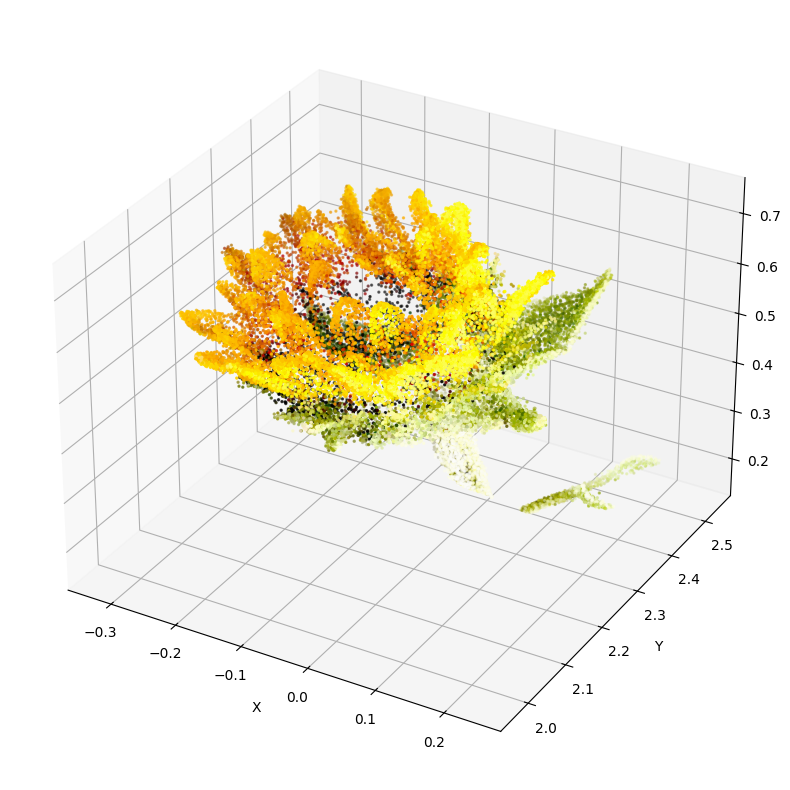

In [50]:
plot_flower()

In [66]:
def solve_pnp(X, x, K=None):
    X=X.to(device)
    x=x.to(device)
    N = X.shape[0]
    x_h=to_homogeneous(x)

    if K is not None:
        K_inv = torch.linalg.inv(K)
        print(K_inv.device)
        x_h = (K_inv @ x_h.T).T 
        

    X_h = torch.cat([X, torch.ones((N,1), dtype=torch.float64,device=device)], dim=1) 
    

    zeros4 = torch.zeros((N,4), device=device, dtype=X.dtype)
    
    u = x_h[:,0].view(-1,1)
    v = x_h[:,1].view(-1,1)
   
    row1 = torch.cat([zeros4, -X_h, v*X_h], dim=1)  
    row2 = torch.cat([X_h, zeros4, -u*X_h], dim=1)  
    
    A = torch.cat([row1, row2], dim=0) 
    

    _, _, Vh = torch.linalg.svd(A)
    P = Vh[-1].reshape(3,4) 
    

    R = P[:,:3]
    t = P[:,3]
    

    U, S, V = torch.linalg.svd(R)
    R = U @ V

    t = t / S.mean()
    torch.cuda.empty_cache()
    return R, t

In [68]:
mask888 = mask(projections[2]['ids'], com_ids_cam01_cam2)
projections[2]['coordinates'].to(device)[mask888].to(torch.float64)

tensor([[-0.0910,  0.9502],
        [-0.1234,  0.8968],
        [-0.0145,  0.9450],
        ...,
        [-0.0788,  0.4329],
        [-0.0761,  0.4280],
        [-0.0693,  0.4350]], device='cuda:0', dtype=torch.float64)

In [70]:
R2 ,t2=solve_pnp(points3d[com_ids_cam01_cam2],projections[2]['coordinates'].to(device)[mask888],K)

cuda:0


In [71]:
R1, t1

(tensor([[ 0.9237,  0.0990,  0.3701],
         [-0.1518,  0.9815,  0.1164],
         [-0.3518, -0.1637,  0.9217]], device='cuda:0', dtype=torch.float64),
 tensor([-0.9432, -0.2718,  0.1910], device='cuda:0', dtype=torch.float64))

In [72]:
R2, t2

(tensor([[-0.6603, -0.1941, -0.7255],
         [ 0.0359, -0.9731,  0.2277],
         [ 0.7502, -0.1243, -0.6495]], device='cuda:0', dtype=torch.float64),
 tensor([ 1.7134, -0.5442, -0.7859], device='cuda:0', dtype=torch.float64))

Теперь мы знаем пооврот и смещение и для первой камеры и для второй
добавим оставшиеся точки в 3д набору

In [74]:
id_3dpoint=torch.nonzero(~torch.isnan(points3d).any(dim=1), as_tuple=True)[0]

In [77]:
projections[2]['coordinates'].to(device)[mask(projections[2]['ids'], com_ids_cam01_cam2)]

tensor([[-0.0910,  0.9502],
        [-0.1234,  0.8968],
        [-0.0145,  0.9450],
        ...,
        [-0.0788,  0.4329],
        [-0.0761,  0.4280],
        [-0.0693,  0.4350]], device='cuda:0')

In [78]:
com_ids_cam0_cam2

tensor([   40,    41,    54,  ..., 76377, 76378, 76379], device='cuda:0')

Добавляем точки общие для камер 0 и 2 и не входящих уже в 3д облако

In [80]:
ids_cam0 = projections[0]['ids'].to(device=device)
ids_cam2 = projections[2]['ids'].to(device=device)

new_ids_0_2 = com_ids_cam0_cam2[~mask(com_ids_cam0_cam2, id_3dpoint)]
mask0 = torch.isin(ids_cam0, new_ids_0_2).to('cpu')
points0_2d = projections[0]['coordinates'][mask0]

mask2 = torch.isin(ids_cam2, new_ids_0_2).to('cpu')
points2_2d = projections[2]['coordinates'][mask2]

points0_norm = to_homogeneous(points0_2d) @ K_inv.T
points2_norm = to_homogeneous(points2_2d) @ K_inv.T

X_new = triangulate_points(points0_norm, points2_norm, R2, t2)

points3d[new_ids_0_2] = X_new

In [83]:
copy_point3d=points3d.clone()

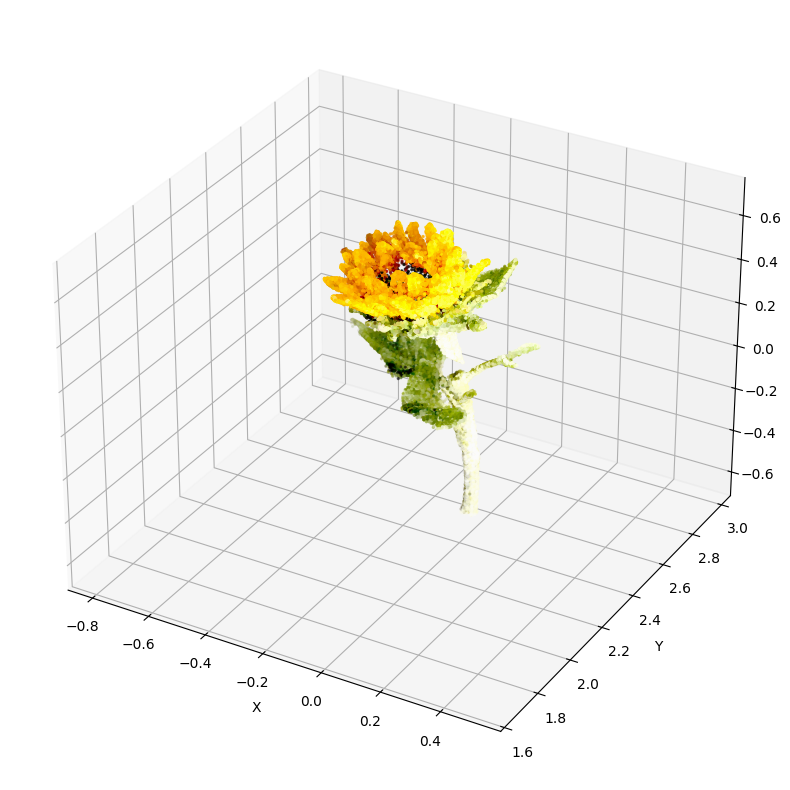

In [81]:
plot_flower()

In [85]:
ids_cam1 = projections[1]['ids'].to(device=device)
ids_cam2 = projections[2]['ids'].to(device=device)

new_ids_1_2 = com_ids_cam1_cam2[ ~mask(com_ids_cam1_cam2, id_3dpoint)]


points1_2d = projections[1]['coordinates'].to(device)[mask(ids_cam1, new_ids_1_2)]



points2_2d = projections[2]['coordinates'].to(device)[mask(ids_cam2, new_ids_1_2)]


points1_norm = to_homogeneous(points1_2d) @ K_inv.T
points2_norm = to_homogeneous(points2_2d) @ K_inv.T

X_new_1_2 = triangulate_points(points1_norm, points2_norm, R2, t2) 

points3d[new_ids_1_2] = X_new_1_2

In [86]:
points3d[76408]

tensor([-0.4416,  0.1653,  2.2173], device='cuda:0', dtype=torch.float64)

In [87]:
mask_nan_points = torch.isnan(points3d).any(dim=1)  # shape (N,)

len(torch.nonzero(mask_nan_points, as_tuple=False).squeeze())

0

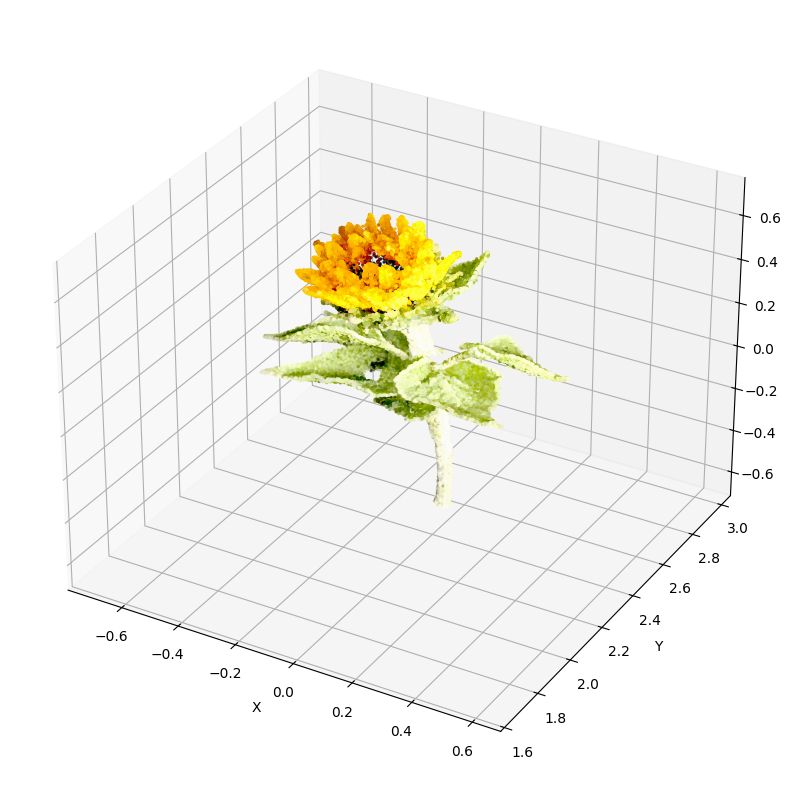

In [89]:
plot_flower()

In [90]:
import numpy as np
points_to_save = points3d.detach().cpu().to(torch.float32).numpy()
np.savetxt("points3d.txt", points_to_save, fmt="%.3f")

ValueError: unknown file extension: 

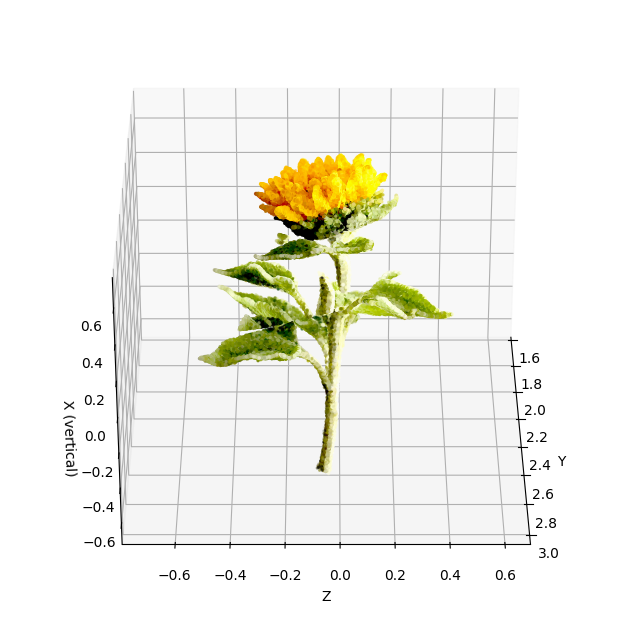

In [91]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import torch
from IPython.display import Image, display

# --- подготовка данных ---
mask_valid = ~torch.isnan(points3d).any(dim=1).to('cpu')
points = points3d[mask_valid].detach().cpu().numpy()
colors = rgbs[mask_valid].detach().cpu().numpy()

if colors.max() > 1.0:
    colors = colors / 255.0

X = points[:, 1]
Y = points[:, 2]
Z = points[:, 0]

Xm = Y
Ym = Z
Zm = X

# --- создаём фигуру ---
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(Xm, Ym, Zm, c=colors, s=2)

ax.set_xlabel("Y")
ax.set_ylabel("Z")
ax.set_zlabel("X (vertical)")

# равный масштаб
max_range = np.array([Xm.max()-Xm.min(),
                      Ym.max()-Ym.min(),
                      Zm.max()-Zm.min()]).max() / 2.0
mid_x = (Xm.max()+Xm.min()) * 0.5
mid_y = (Ym.max()+Ym.min()) * 0.5
mid_z = (Zm.max()+Zm.min()) * 0.5
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)

# --- функция вращения ---
def update(frame):
    ax.view_init(elev=30, azim=frame)
    return sc,

# --- создаём анимацию ---
ani = FuncAnimation(fig, update, frames=np.arange(0, 360, 2), interval=50, blit=False)

# --- сохраняем в GIF ---
ani.save("cloud3d-3gif", writer=PillowWriter(fps=20))

# --- отображаем GIF в Colab ---
display(Image("cloud3d-3.gif"))